In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset I pulled from NYC 311 system

In [3]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/SI 313 HW/si313_w26/assignment_template_notebooks/311_Service_Request_2025.csv")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26868\434402309.py:1: DtypeWarning: Columns (0: Incident Zip, 1: Facility Type, 2: Due Date, 3: Taxi Company Borough, 4: Road Ramp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/ADMIN/Desktop/SI 313 HW/si313_w26/assignment_template_notebooks/311_Service_Request_2025.csv")


## Explore Data

First I started exploring the dataset to see which columns (variables) are needed for my analysis since I'm going to focus only on temporal patterns

In [4]:
df.shape

(3654871, 44)

In [5]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,67351589,12/31/2025 11:44:49 PM,01/01/2026 12:51:55 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,11214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.600868,-74.003338,POINT (-74.003338217285 40.600868498932)
1,67353072,12/31/2025 11:44:46 PM,01/01/2026 12:40:19 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,10033.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.852551,-73.932965,POINT (-73.932964947406 40.852551285878)
2,67353134,12/31/2025 11:44:31 PM,01/03/2026 11:00:00 PM,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HEAT,RESIDENTIAL BUILDING,11230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.627084,-73.956662,POINT (-73.956661780231 40.627084136449)
3,67349190,12/31/2025 11:44:29 PM,01/01/2026 01:16:00 AM,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,NaN,Street/Sidewalk,10459.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.832075,-73.895512,POINT (-73.895512413161 40.832075356358)
4,67352362,12/31/2025 11:44:28 PM,01/01/2026 03:32:09 AM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,11365.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.731322,-73.795696,POINT (-73.795695694932 40.731322231992)


In [6]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Council District', 'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Open Data Channel Type', 'Park Facility Name', 'Park Borough', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Latitude', 'Longitude', 'Location']


In [ ]:
#Select only needed columns
df = df[[
    "Problem (formerly Complaint Type)",
    "Created Date",
    "Incident Zip"
]].copy()

#Rename column to make it easier
df.rename(columns={
    "Problem (formerly Complaint Type)": "Complaint Type"
}, inplace=True)

#Drop missing values
df = df.dropna(subset=["Complaint Type", "Created Date", "Incident Zip"])

#Clean ZIP code (keep first 5 digits)
df["Incident Zip"] = df["Incident Zip"].astype(str).str[:5]

#Convert date to datetime
df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")

#Drop rows where date failed
df = df.dropna(subset=["Created Date"])

#Extract time features
df["Month"] = df["Created Date"].dt.month
df["Hour"] = df["Created Date"].dt.hour

#Final check
print("Cleaned dataset shape:")
print(df.shape)

print("\nSample:")
print(df.head())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26868\588497440.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")


Cleaned dataset shape:
(3624989, 5)

Sample:
            Complaint Type        Created Date Incident Zip  Month  Hour
0         Blocked Driveway 2025-12-31 23:44:49        11214     12    23
1  Noise - Street/Sidewalk 2025-12-31 23:44:46        10033     12    23
2           HEAT/HOT WATER 2025-12-31 23:44:31        11230     12    23
3          Illegal Parking 2025-12-31 23:44:29        10459     12    23
4      Noise - Residential 2025-12-31 23:44:28        11365     12    23


## First Analysis

In [ ]:
#Top 10 complaint types
top_complaints = df["Complaint Type"].value_counts().head(10)

print("\nTop 10 complaint types:")
print(top_complaints)


Top 10 complaint types:
Complaint Type
Illegal Parking            577245
Noise - Residential        463297
HEAT/HOT WATER             315909
Noise - Street/Sidewalk    173038
Blocked Driveway           172715
UNSANITARY CONDITION       117721
Water System                77506
Street Condition            69581
PLUMBING                    69532
Abandoned Vehicle           67838
Name: count, dtype: int64


After converting created_date to datettime format, I also checked for any missing values in both key volumns.

In [ ]:
#Check if there are missing values in the 'created_date' column
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")

df.dropna(subset=['Created Date', 'Complaint Type'], inplace=True)
print(f"Total rows after cleaning: {len(df)}")


Complaint Type    0
Created Date      0
Incident Zip      0
Month             0
Hour              0
dtype: int64

Total rows before cleaning: 3624989
Total rows after cleaning: 3624989


## Visualization 1

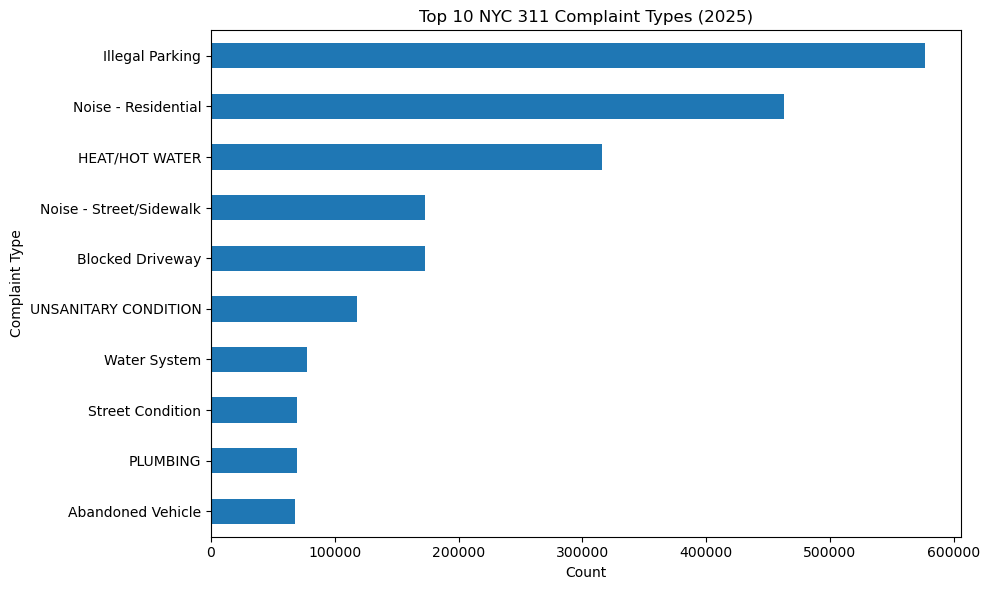

In [ ]:
import matplotlib.pyplot as plt

#Plot top complaints
plt.figure(figsize=(10,6))
top_complaints.sort_values().plot(kind="barh")

plt.title("Top 10 NYC 311 Complaint Types (2025)")
plt.xlabel("Count")
plt.ylabel("Complaint Type")

plt.tight_layout()
plt.savefig("top_complaints_chart.png")
plt.show()

## Second Analysis

In [ ]:
#Find top 5 ZIP codes
top_zips = df["Incident Zip"].value_counts().head(5).index.tolist()

print("\nTop 5 ZIP codes:")
print(top_zips)

#Filter data for these ZIP codes
zip_df = df[df["Incident Zip"].isin(top_zips)].copy()

#Count complaints by ZIP and type
zip_complaints = (
    zip_df.groupby(["Incident Zip", "Complaint Type"])
    .size()
    .reset_index(name="Count")
)

#Get top 5 complaint types per ZIP
top_zip_complaints = (
    zip_complaints.sort_values(["Incident Zip", "Count"], ascending=[True, False])
    .groupby("Incident Zip")
    .head(5)
)

print("\nTop complaint types per ZIP:")
print(top_zip_complaints)


Top 5 ZIP codes:
['10466', '11226', '10452', '10467', '10468']

Top complaint types per ZIP:
    Incident Zip           Complaint Type   Count
48         10452           HEAT/HOT WATER    8980
79         10452      Noise - Residential    5361
80         10452  Noise - Street/Sidewalk    4987
117        10452     UNSANITARY CONDITION    4416
56         10452          Illegal Parking    3785
202        10466      Noise - Residential  127228
180        10466          Illegal Parking    4765
173        10466           HEAT/HOT WATER    4103
136        10466         Blocked Driveway    2459
239        10466     UNSANITARY CONDITION    1361
309        10467           HEAT/HOT WATER    9231
339        10467      Noise - Residential    7038
317        10467          Illegal Parking    5136
382        10467     UNSANITARY CONDITION    2816
340        10467  Noise - Street/Sidewalk    2434
446        10468           HEAT/HOT WATER    8911
476        10468      Noise - Residential    6625
453   

## Second Visualization


Pivot table for ZIP comparison:
Incident Zip              10452     10466   10467   10468   11226
Complaint Type                                                   
Blocked Driveway            0.0    2459.0     0.0     0.0     0.0
HEAT/HOT WATER           8980.0    4103.0  9231.0  8911.0  9354.0
Illegal Parking          3785.0    4765.0  5136.0  5521.0  5263.0
Noise - Residential      5361.0  127228.0  7038.0  6625.0  5750.0
Noise - Street/Sidewalk  4987.0       0.0  2434.0  4000.0  3019.0
UNSANITARY CONDITION     4416.0    1361.0  2816.0  2373.0  3814.0


<Figure size 1200x700 with 0 Axes>

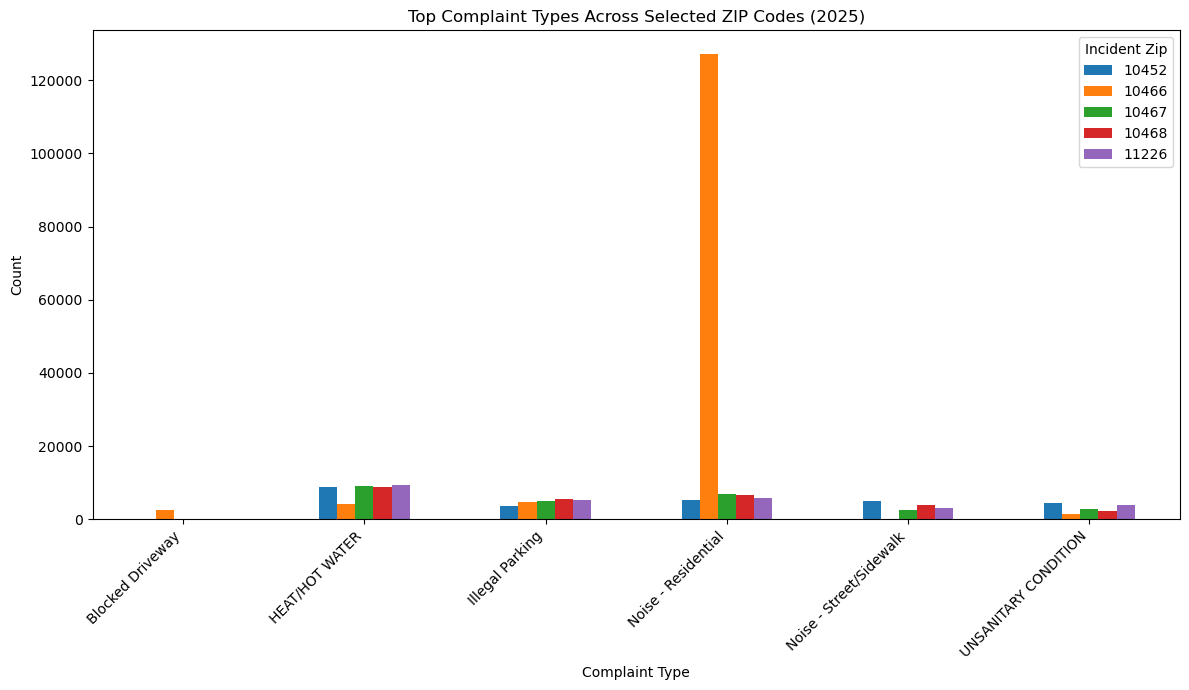

In [ ]:
#Pivot table for chart
pivot_zip = top_zip_complaints.pivot(
    index="Complaint Type",
    columns="Incident Zip",
    values="Count"
).fillna(0)

print("\nPivot table for ZIP comparison:")
print(pivot_zip)

#Plot chart
plt.figure(figsize=(12, 7))
pivot_zip.plot(kind="bar", figsize=(12, 7))

plt.title("Top Complaint Types Across Selected ZIP Codes (2025)")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("zip_comparison_chart.png")
plt.show()

## Third Analysis


Monthly complaint counts:
Month
1     345844
2     252979
3     278672
4     269928
5     292403
6     303909
7     313438
8     301656
9     300108
10    333902
11    302445
12    329705
dtype: int64


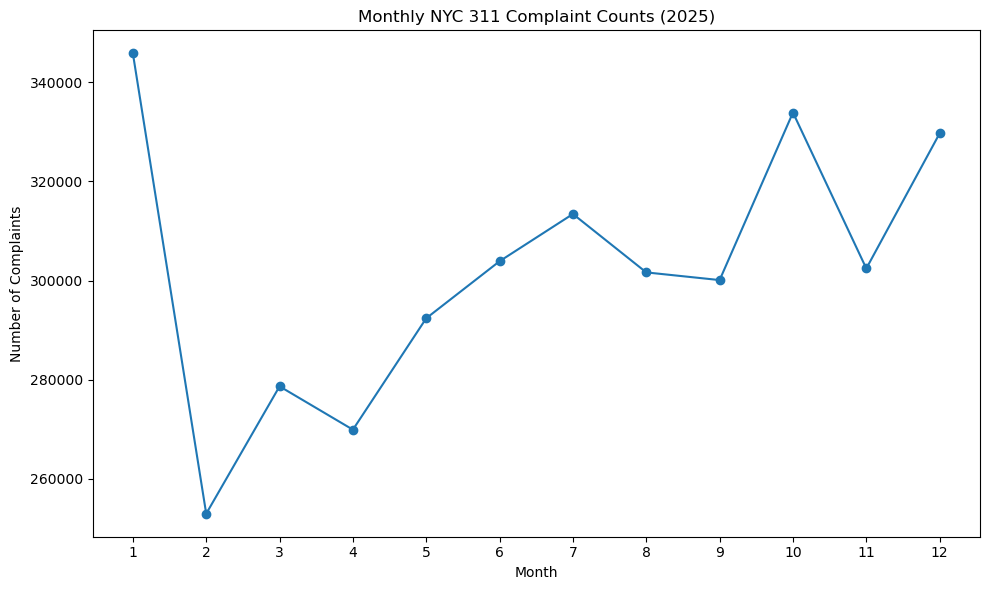

In [13]:
# Group by month
monthly_counts = df.groupby("Month").size()

print("\nMonthly complaint counts:")
print(monthly_counts)

# Plot
plt.figure(figsize=(10,6))
monthly_counts.plot(kind="line", marker="o")

plt.title("Monthly NYC 311 Complaint Counts (2025)")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")

plt.xticks(range(1,13))
plt.tight_layout()

plt.savefig("monthly_trend_chart.png")
plt.show()

In [14]:
from scipy.stats import chi2_contingency
import pandas as pd

# Top 5 ZIP codes by total complaints
top_zips = df["Incident Zip"].value_counts().head(5).index

# Main complaint types from your analysis
major_types = ["HEAT/HOT WATER", "Illegal Parking", "Noise - Residential"]

# Filter dataset
zip_type_df = df[
    (df["Incident Zip"].isin(top_zips)) &
    (df["Complaint Type"].isin(major_types))
]

# Create contingency table
complaint_zip_table = pd.crosstab(
    zip_type_df["Incident Zip"],
    zip_type_df["Complaint Type"]
)

# Run chi-square test
chi2, p, dof, expected = chi2_contingency(complaint_zip_table)

print(complaint_zip_table)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)


Complaint Type  HEAT/HOT WATER  Illegal Parking  Noise - Residential
Incident Zip                                                        
10452                     8980             3785                 5361
10466                     4103             4765               127228
10467                     9231             5136                 7038
10468                     8911             5521                 6625
11226                     9354             5263                 5750
Chi-square statistic: 96874.64206358239
p-value: 0.0
Degrees of freedom: 8


## [External Source] Income Data For NYC in 5 years from 2020-2024 ##

In [15]:
income_df = pd.read_csv("C:/Users/ADMIN/Desktop/SI 313 HW/si313_w26/assignment_template_notebooks/ACSDT5Y2024.B19013-Data.csv")
print(income_df.head())
print(income_df.columns)

           GEO_ID                  NAME  \
0       Geography  Geographic Area Name   
1  860Z200US06390           ZCTA5 06390   
2  860Z200US10001           ZCTA5 10001   
3  860Z200US10002           ZCTA5 10002   
4  860Z200US10003           ZCTA5 10003   

                                         B19013_001E  \
0  Estimate!!Median household income in the past ...   
1                                              98125   
2                                             129852   
3                                              48386   
4                                             154262   

                                         B19013_001M  Unnamed: 4  
0  Margin of Error!!Median household income in th...         NaN  
1                                              59611         NaN  
2                                              25244         NaN  
3                                               4836         NaN  
4                                              10754         NaN  
In

**Clean dataset**

In [16]:
# Keep only the useful columns
income_df = income_df[["NAME", "B19013_001E"]].copy()

# Rename columns
income_df.rename(columns={
    "NAME": "ZCTA",
    "B19013_001E": "Median Income"
}, inplace=True)

# Remove the first row that contains text labels, not actual data
income_df = income_df.iloc[1:].copy()

# Extract ZIP code from strings like "ZCTA5 10001"
income_df["Incident Zip"] = income_df["ZCTA"].str[-5:]

# Convert median income to numeric
income_df["Median Income"] = pd.to_numeric(income_df["Median Income"], errors="coerce")

# Drop missing values
income_df = income_df.dropna(subset=["Incident Zip", "Median Income"])

# Check result
print(income_df.head())
print(income_df.shape)

          ZCTA  Median Income Incident Zip
1  ZCTA5 06390        98125.0        06390
2  ZCTA5 10001       129852.0        10001
3  ZCTA5 10002        48386.0        10002
4  ZCTA5 10003       154262.0        10003
6  ZCTA5 10005       190233.0        10005
(1617, 3)


In [17]:
zip_summary = df.groupby("Incident Zip").size().reset_index(name="Total Complaints")

print(zip_summary.head())
print(zip_summary.shape)

  Incident Zip  Total Complaints
0        10000               765
1        10001             21577
2        10002             28781
3        10003             25466
4        10004              6437
(345, 2)


In [18]:
# Count specific complaint types per ZIP
complaint_types = ["HEAT/HOT WATER", "Noise - Residential", "Illegal Parking"]

zip_complaints = (
    df[df["Complaint Type"].isin(complaint_types)]
    .groupby(["Incident Zip", "Complaint Type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(zip_complaints.head())

Complaint Type Incident Zip  HEAT/HOT WATER  Illegal Parking  \
0                     10000               1                7   
1                     10001             383             1954   
2                     10002            1406             2954   
3                     10003            1733             1579   
4                     10004              21              828   

Complaint Type  Noise - Residential  
0                                 5  
1                              1571  
2                              3798  
3                              1880  
4                               172  


In [19]:
zip_full = pd.merge(zip_summary, zip_complaints, on="Incident Zip", how="left")

In [20]:
merged_df = pd.merge(zip_full, income_df, on="Incident Zip", how="inner")

print(merged_df.head())
print(merged_df.shape)

  Incident Zip  Total Complaints  HEAT/HOT WATER  Illegal Parking  \
0        10001             21577           383.0           1954.0   
1        10002             28781          1406.0           2954.0   
2        10003             25466          1733.0           1579.0   
3        10005              3507            28.0            439.0   
4        10006              2869            51.0            328.0   

   Noise - Residential         ZCTA  Median Income  
0               1571.0  ZCTA5 10001       129852.0  
1               3798.0  ZCTA5 10002        48386.0  
2               1880.0  ZCTA5 10003       154262.0  
3                165.0  ZCTA5 10005       190233.0  
4                 89.0  ZCTA5 10006       190170.0  
(223, 7)


In [21]:
merged_df["Income Group"] = pd.qcut(
    merged_df["Median Income"],
    3,
    labels=["Low", "Medium", "High"]
)

merged_df.groupby("Income Group")["Total Complaints"].mean()


Income Group
Low       26613.586667
Medium    12833.013514
High       8885.364865
Name: Total Complaints, dtype: float64

In [22]:
merged_df["Total Complaints"].corr(merged_df["Median Income"])

np.float64(-0.4223092927701147)

In [23]:
merged_df["HEAT/HOT WATER"].corr(merged_df["Median Income"])
merged_df["Noise - Residential"].corr(merged_df["Median Income"])

np.float64(-0.14378255868324455)

In [24]:
df_full = pd.merge(df, income_df, on="Incident Zip", how="inner")

In [25]:
df_full["Income Group"] = pd.qcut(
    df_full["Median Income"],
    3,
    labels=["Low", "Medium", "High"]
)

In [26]:
complaint_by_income = (
    df_full.groupby(["Income Group", "Complaint Type"])
    .size()
    .reset_index(name="Count")
)

In [27]:
top_complaints_income = (
    complaint_by_income
    .sort_values(["Income Group", "Count"], ascending=[True, False])
    .groupby("Income Group")
    .head(5)
)

print(top_complaints_income)

    Income Group           Complaint Type   Count
102          Low      Noise - Residential  276075
67           Low           HEAT/HOT WATER  165988
75           Low          Illegal Parking  146319
103          Low  Noise - Street/Sidewalk   81287
156          Low     UNSANITARY CONDITION   63169
245       Medium          Illegal Parking  186427
272       Medium      Noise - Residential   98610
237       Medium           HEAT/HOT WATER   94456
188       Medium         Blocked Driveway   78900
273       Medium  Noise - Street/Sidewalk   52308
417         High          Illegal Parking  241665
445         High      Noise - Residential   88310
409         High           HEAT/HOT WATER   55396
358         High         Blocked Driveway   44202
446         High  Noise - Street/Sidewalk   39088


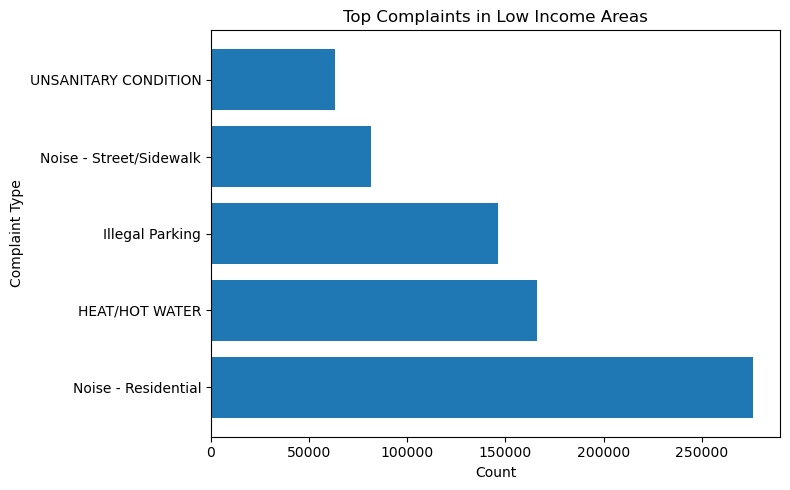

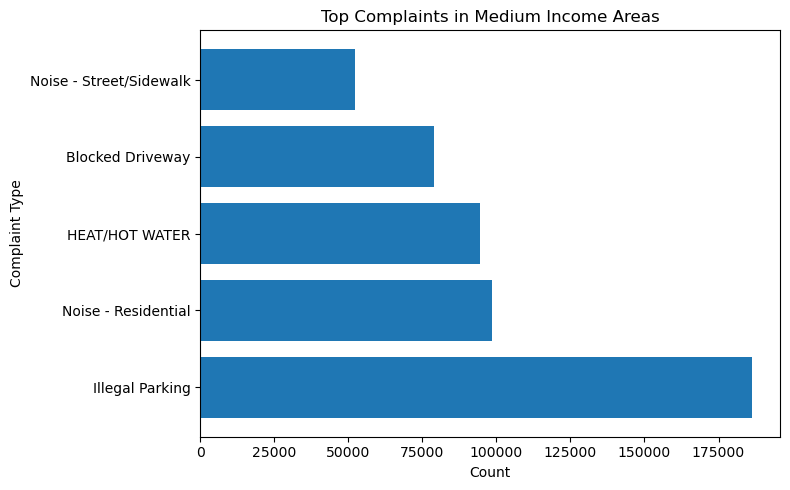

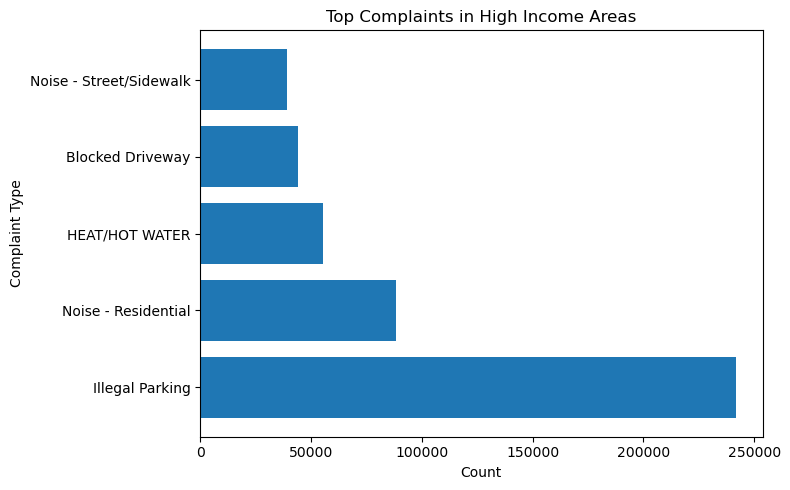

In [28]:
import matplotlib.pyplot as plt

for group in ["Low", "Medium", "High"]:
    subset = top_complaints_income[top_complaints_income["Income Group"] == group]
    
    plt.figure(figsize=(8,5))
    plt.barh(subset["Complaint Type"], subset["Count"])
    plt.title(f"Top Complaints in {group} Income Areas")
    plt.xlabel("Count")
    plt.ylabel("Complaint Type")
    plt.tight_layout()
    plt.show()

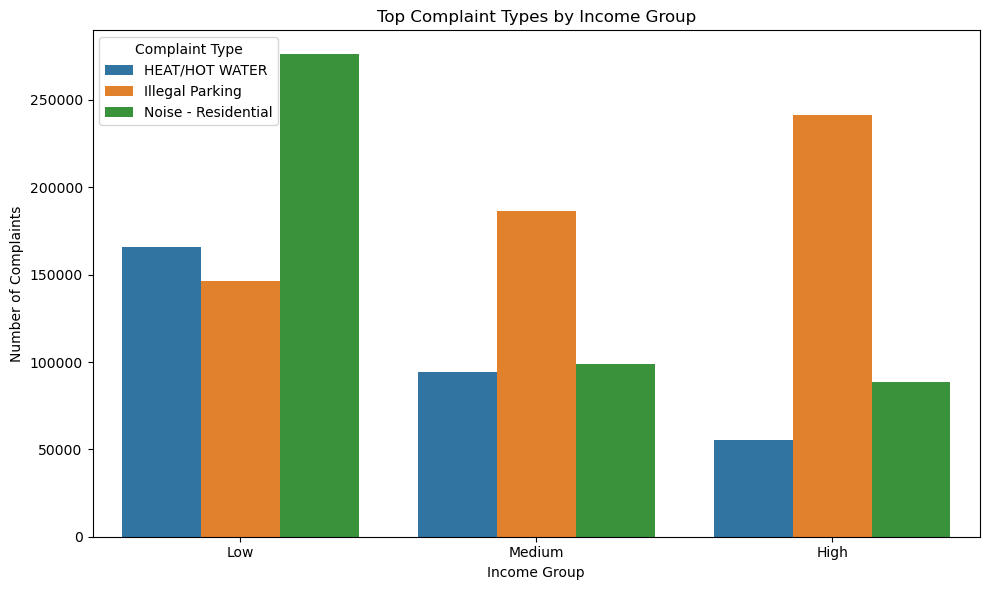

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only the top complaint types I want to compare
selected_types = [
    "Noise - Residential",
    "HEAT/HOT WATER",
    "Illegal Parking"
]

plot_data = complaint_by_income[
    complaint_by_income["Complaint Type"].isin(selected_types)
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Income Group",
    y="Count",
    hue="Complaint Type"
)

plt.title("Top Complaint Types by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Complaints")
plt.legend(title="Complaint Type")
plt.tight_layout()
plt.show()


## Another ANOVA test ##

In [30]:
from scipy.stats import f_oneway

In [31]:
low = merged_df[merged_df["Income Group"] == "Low"]["Total Complaints"]
medium = merged_df[merged_df["Income Group"] == "Medium"]["Total Complaints"]
high = merged_df[merged_df["Income Group"] == "High"]["Total Complaints"]

f_stat, p_value = f_oneway(low, medium, high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 30.99418037505231
p-value: 1.3837727394753744e-12


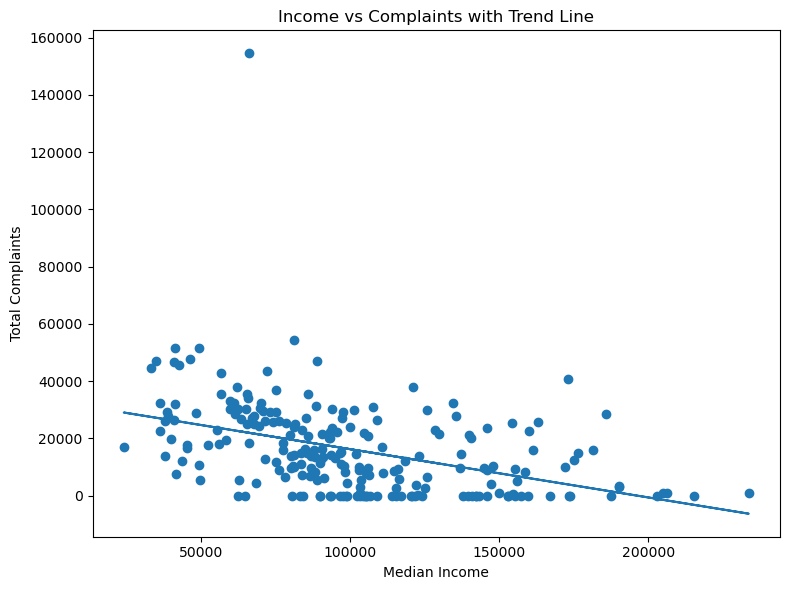

In [32]:
import numpy as np

x = merged_df["Median Income"]
y = merged_df["Total Complaints"]

# Fit line
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y)

plt.plot(x, m*x + b)

plt.xlabel("Median Income")
plt.ylabel("Total Complaints")
plt.title("Income vs Complaints with Trend Line")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

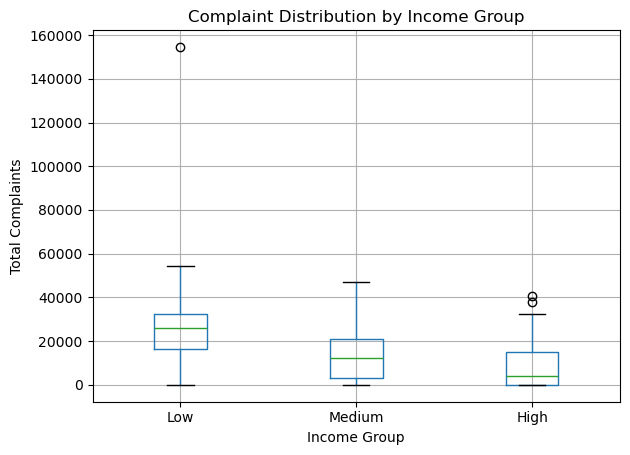

In [33]:
plt.figure(figsize=(8,6))

merged_df.boxplot(column="Total Complaints", by="Income Group")

plt.title("Complaint Distribution by Income Group")
plt.suptitle("")  # removes automatic title

plt.xlabel("Income Group")
plt.ylabel("Total Complaints")

plt.tight_layout()
plt.show()